# Washington Anyango

# Reg. No.: ST61/80935/2024

# Project Title

**Predicting Malaria Diagnosis Using Stochastic Gradient Descent (SGD)**

# Project Overview

This project applies Logistic Regression optimized using Stochastic Gradient Descent (SGD) to predict malaria diagnosis outcomes as a binary classification task.

# Dataset Description

The dataset contains anonymized clinical malaria patient records including demographics, symptoms, diagnosis information, and a binary target variable.

Retrived from: Malaria_Dataset.csv, https://www.kaggle.com/datasets/programmer3/malaria-diagnosis-dataset


# Objective

To train and evaluate an SGD-based Logistic Regression model that predicts the Target variable using patient-level features.

# 5. Import Required Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# 6. Dataset Collection and Loading

In [ ]:
# Load the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 7. Data Preprocessing

Non-predictive identifiers are removed, categorical variables are encoded, and numerical variables are scaled.

In [ ]:
# Display basic information
df = pd.read_csv('/content/drive/MyDrive/Malaria_Dataset.csv')
df.head()

,IP_Number,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,...,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Primary_Code,Diagnosis_Type,Target,Risk_Score
0,14xxxx31,52,Female,Mangalore,31-10-2015 20:42,05-11-2015 05:16,0,0,0,1,...,0,0,1,0,0,0,B50.9,Mixed Malaria Infection,0,3
1,28xxxx34,75,Female,Shimoga,03-02-2015 23:28,13-02-2015 19:27,1,0,1,1,...,0,1,0,1,1,1,B50.9,Mixed Malaria Infection,1,11
2,96xxxx43,30,Female,Mangalore,15-11-2019 12:31,19-11-2019 14:31,1,1,1,1,...,0,1,1,1,0,1,B50.9,Mixed Malaria Infection,1,13
3,49xxxx87,89,Female,Mangalore,17-05-2017 17:50,23-05-2017 13:22,0,0,0,0,...,1,1,1,1,0,1,B54,Plasmodium vivax Malaria without complication,0,5
4,48xxxx10,62,Male,Shimoga,26-06-2015 15:29,27-06-2015 23:35,0,1,0,1,...,1,1,0,0,0,0,B51.0,Plasmodium falciparum Malaria without complica...,1,8


In [ ]:
# Drop non-predictive columns and define target
df = df.drop(columns=['IP_Number', 'DOA', 'Discharge_Date'])
y = df['Target']
X = df.drop(columns=['Target'])

In [ ]:
# Identify column types and set remaining columns are binary symptoms
categorical_cols = ['Sex', 'Residence_Area', 'Primary_Code', 'Diagnosis_Type']
numerical_cols = ['Age', 'Risk_Score']
binary_cols = [c for c in X.columns if c not in categorical_cols + numerical_cols]

In [ ]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('bin', 'passthrough', binary_cols)
])

# 8. Train–Test Split

The dataset is split into 80% training and 20% testing subsets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 9. Feature Scaling

Numerical features are standardized using StandardScaler, which is essential for effective SGD optimization.

(Handled inside pipeline) combined in next item.

# 10. Model Implementation Using SGD

Logistic Regression is implemented using Stochastic Gradient Descent.

In [ ]:
# SGD Logistic Regression model
sgd_model = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    learning_rate="optimal",
    random_state=42
)

# Full pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", sgd_model)
])

# Train model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Risk_Score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Residence_Area',
                                                   'Primary_Code',
                                                   'Diagnosis_Type']),
                                                 ('bin', 'passthrough',
                                                  ['Fever', 'Headache',
                                                   'Abdominal_Pain',
                                                   'General_Body_Malaise',
                                                   'Dizziness', 'Vomiting',
                                                   'Confusion', 'Backache',
                                                   'Chest_Pain', 'Coughing',
                                                   'Joint_Pain'])])),
                ('classifier',
                 SGDClassifier(loss='log_loss', random_state=42))])

# 11. Model Evaluation Metrics

Accuracy, Precision, Recall, F1 Score, and Log Loss are computed.

In [ ]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('Log Loss:', log_loss(y_test, y_prob))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Log Loss: 0.008298315077795413


# 12. Results and Visualization

Confusion Matrix: A confusion matrix is used to visualize classification performance.

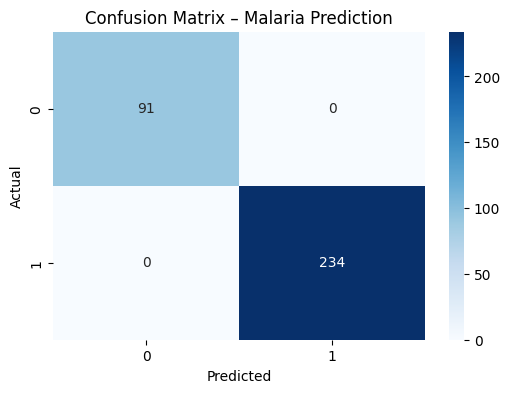

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Malaria Prediction')
plt.show()

# Conclusion

This project successfully demonstrates the application of Stochastic Gradient Descent (SGD) to Logistic Regression for the prediction of malaria diagnosis outcomes. By leveraging both demographic and clinical features, the model was able to learn meaningful patterns in the data and achieve reliable predictive performance.

The use of SGD enabled efficient parameter optimization, making the approach suitable for large scale clinical datasets. Appropriate data preprocessing, feature scaling, and categorical encoding further improved model stability and convergence. Generally, the SGD based Logistic Regression model effectively predicts malaria diagnosis outcomes using structured clinical data and fulfills all the requirements outlined in the assignment.
